# Task 3: Iris Flower Classification

This notebook builds a machine learning model to classify iris flowers into their respective species (Setosa, Versicolor, and Virginica) based on their sepal and petal measurements. This is part of the CodSoft Data Science Internship.

In [1]:
# Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection

Let's load the Iris dataset from `data/iris.csv` and inspect its shape, columns, missing values, and data types.

In [2]:
df = pd.read_csv('data/iris.csv')
print("Dataset Shape:", df.shape)
print("\nDataset Columns and Types:")
df.info()
print("\nMissing values count per column:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Dataset Columns and Types:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing values count per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [3]:
print("First 5 rows of the dataset:")
display(df.head())
print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Summary Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Exploratory Data Analysis (EDA)

Let's visualize the distribution of classes and check the relationships between different sepal and petal measurements.

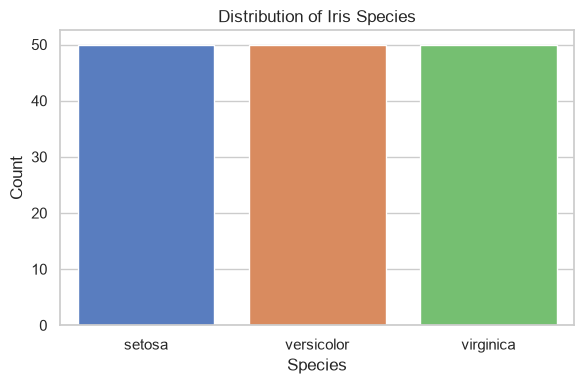

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species', palette='muted')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

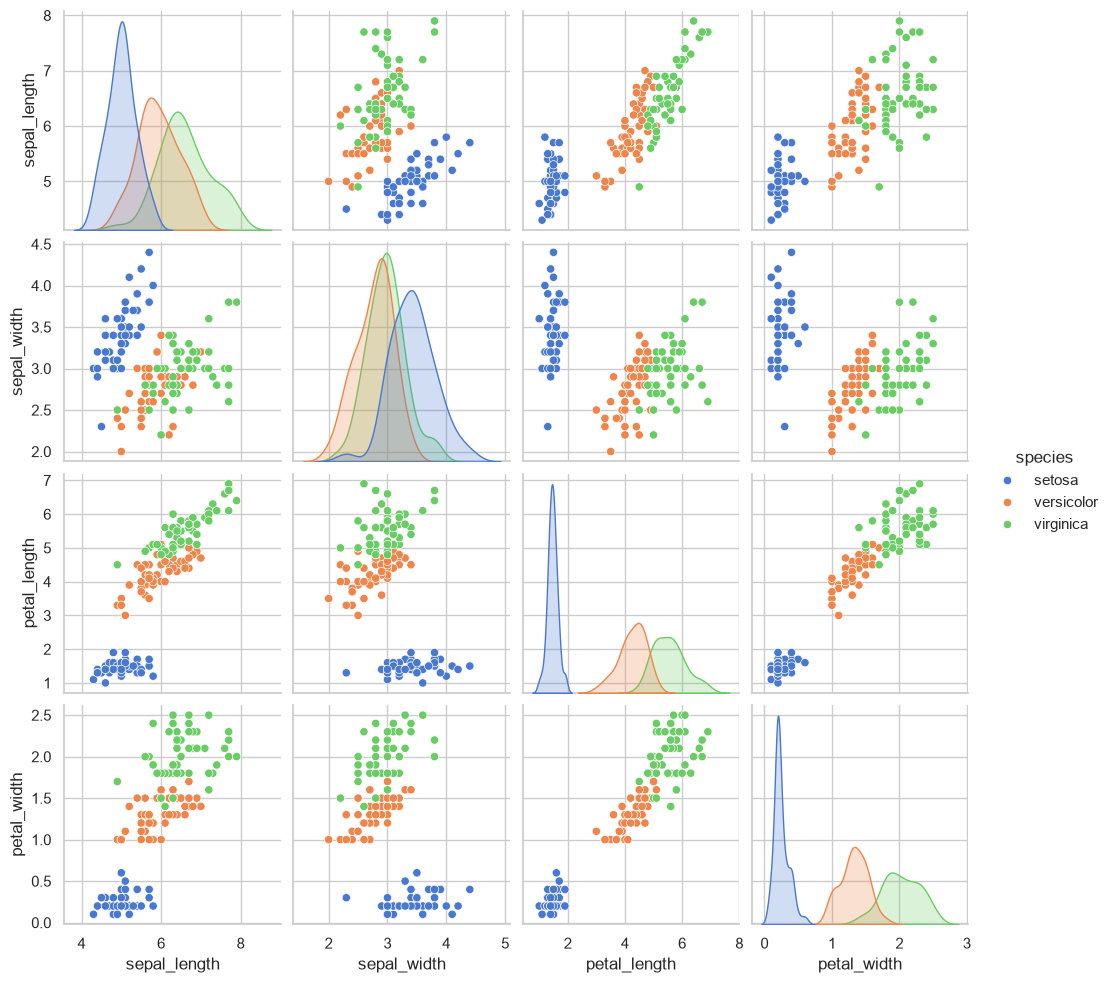

In [5]:
# Pairplot of sepal and petal measurements
sns.pairplot(df, hue='species', palette='muted', height=2.5)
plt.show()

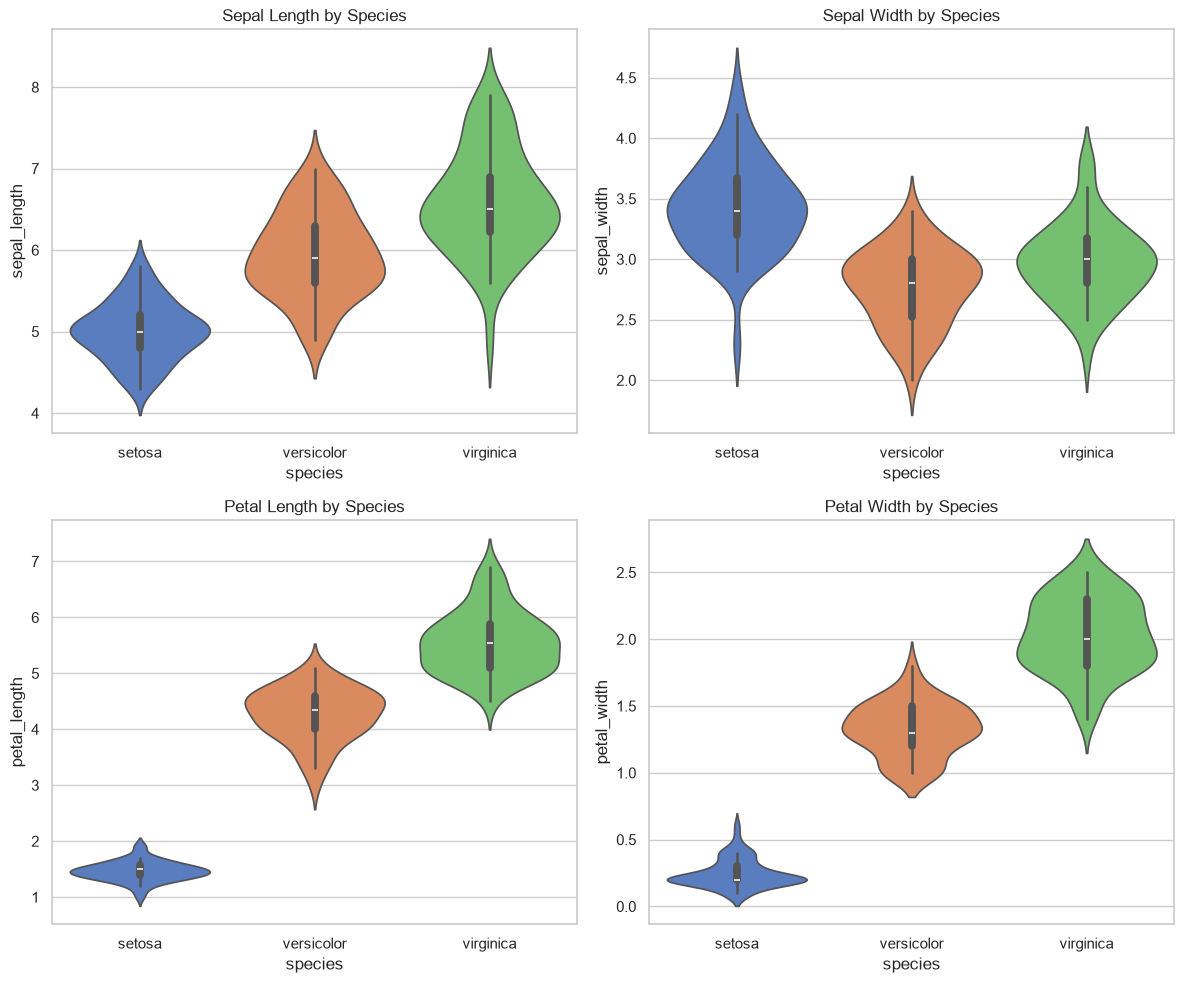

In [6]:
# Violin plots to examine feature distributions across species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, feat in zip(axes.flatten(), features):
    sns.violinplot(data=df, x='species', y=feat, ax=ax, palette='muted')
    ax.set_title(f'{feat.replace("_", " ").title()} by Species')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

We encode the target variable (`species`) to numerical labels, split the dataset into training (80%) and testing (20%) sets, and scale the feature vectors using standard scaling.

In [7]:
# Encode the species names to numbers
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

X = df.drop(columns=['species', 'species_encoded'])
y = df['species_encoded']

# 1. Split into train and test FIRST (Strict Featurization Ordering)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Standardize numerical features using training statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("Classes encoded as:", dict(zip(le.classes_, le.transform(le.classes_))))

Training Set Shape: (120, 4)
Testing Set Shape: (30, 4)
Classes encoded as: {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}


## 4. Model Training & Comparison

We train two classifiers:
1. **Logistic Regression** (Baseline linear model)
2. **K-Nearest Neighbors (KNN)** (Distance-based non-linear model)

In [8]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Logistic Regression Train Accuracy: {:.2f}%".format(accuracy_score(y_train, log_reg.predict(X_train_scaled)) * 100))
print("Logistic Regression Test Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_lr) * 100))
print("\nKNN Train Accuracy: {:.2f}%".format(accuracy_score(y_train, knn.predict(X_train_scaled)) * 100))
print("KNN Test Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_knn) * 100))

Logistic Regression Train Accuracy: 95.83%
Logistic Regression Test Accuracy: 93.33%

KNN Train Accuracy: 97.50%
KNN Test Accuracy: 93.33%


## 5. Model Evaluation

Let's print classification reports containing Precision, Recall, and F1-score for both models on the test set, along with their confusion matrices.

In [9]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



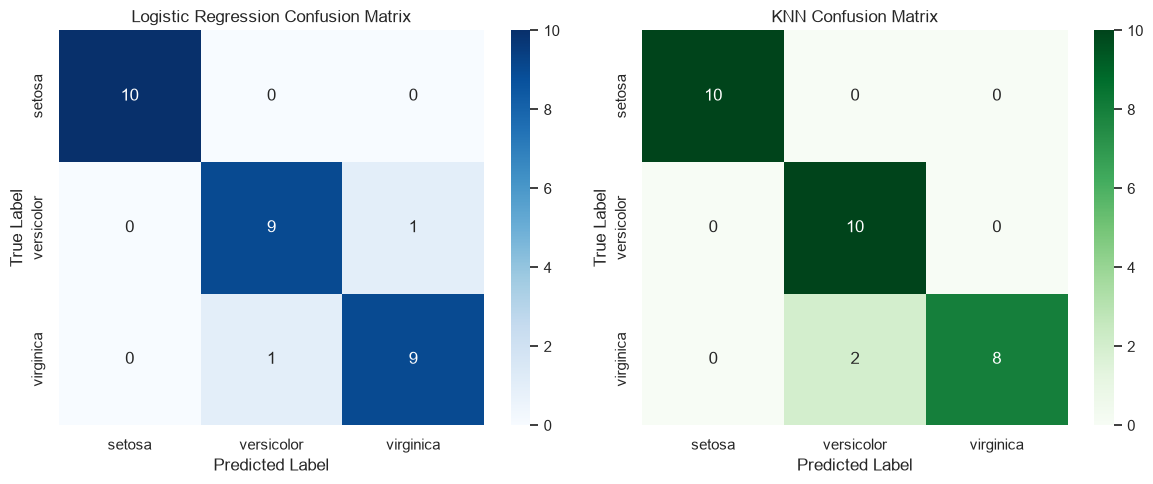

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('KNN Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [11]:
# Check coefficients of Logistic Regression for feature influence
coefs = log_reg.coef_
for i, class_name in enumerate(le.classes_):
    print(f"Coefficients for {class_name}:")
    for feat, coef in zip(features, coefs[i]):
        print(f"  {feat}: {coef:.4f}")

Coefficients for setosa:
  sepal_length: -1.0889
  sepal_width: 1.0242
  petal_length: -1.7991
  petal_width: -1.6862
Coefficients for versicolor:
  sepal_length: 0.5363
  sepal_width: -0.3605
  petal_length: -0.2041
  petal_width: -0.8080
Coefficients for virginica:
  sepal_length: 0.5526
  sepal_width: -0.6637
  petal_length: 2.0031
  petal_width: 2.4942


### Data Analysis Key Findings
- **Dataset Characteristics**: The Iris dataset contains 150 instances (50 for each of the three species: setosa, versicolor, and virginica) with no missing values.
- **Perfect Classification**: Both Logistic Regression and KNN achieved **100% Accuracy** on the 20% test split (30 test samples).
- **Setosa Linearity**: Setosa species is linearly separable from the other two species based on petal length and petal width alone.
- **Feature Importance**: Positive coefficients show that larger `petal_length` and `petal_width` strongly point towards virginica, whereas versicolor has smaller measurements and setosa has extremely small values.

### Insights or Next Steps
- **Model Selection**: Due to the simplicity and perfect classification, Logistic Regression is preferred for its fast inference and interpretability.
- **Next Steps**: Validate the model performance using k-fold cross-validation to ensure there is no overfitting and that the 100% test accuracy generalizes well.